# importations

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer

In [2]:
!pip install scikit-learn


You should consider upgrading via the 'C:\Users\Admin\nest\Venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\Admin\nest\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


# first 5 data

In [4]:
df = pd.read_csv("train.csv")
print(df.head())



   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

# describe

In [9]:
print(df.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

# shape

In [7]:
df.shape

(1460, 81)

# information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# corelation

In [5]:
import pandas as pd


df = pd.read_csv("train.csv")

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                     Id  MSSubClass  LotFrontage   LotArea  OverallQual  \
Id             1.000000    0.011156    -0.010601 -0.033226    -0.028365   
MSSubClass     0.011156    1.000000    -0.386347 -0.139781     0.032628   
LotFrontage   -0.010601   -0.386347     1.000000  0.426095     0.251646   
LotArea       -0.033226   -0.139781     0.426095  1.000000     0.105806   
OverallQual   -0.028365    0.032628     0.251646  0.105806     1.000000   
OverallCond    0.012609   -0.059316    -0.059213 -0.005636    -0.091932   
YearBuilt     -0.012713    0.027850     0.123349  0.014228     0.572323   
YearRemodAdd  -0.021998    0.040581     0.088866  0.013788     0.550684   
MasVnrArea    -0.050298    0.022936     0.193458  0.104160     0.411876   
BsmtFinSF1    -0.005024   -0.069836     0.233633  0.214103     0.239666   
BsmtFinSF2    -0.005968   -0.065649     0.049900  0.111170    -0.059119   
BsmtUnfSF     -0.007940   -0.140759     0.132644 -0.002618     0.308159   
TotalBsmtSF   -0.015415  

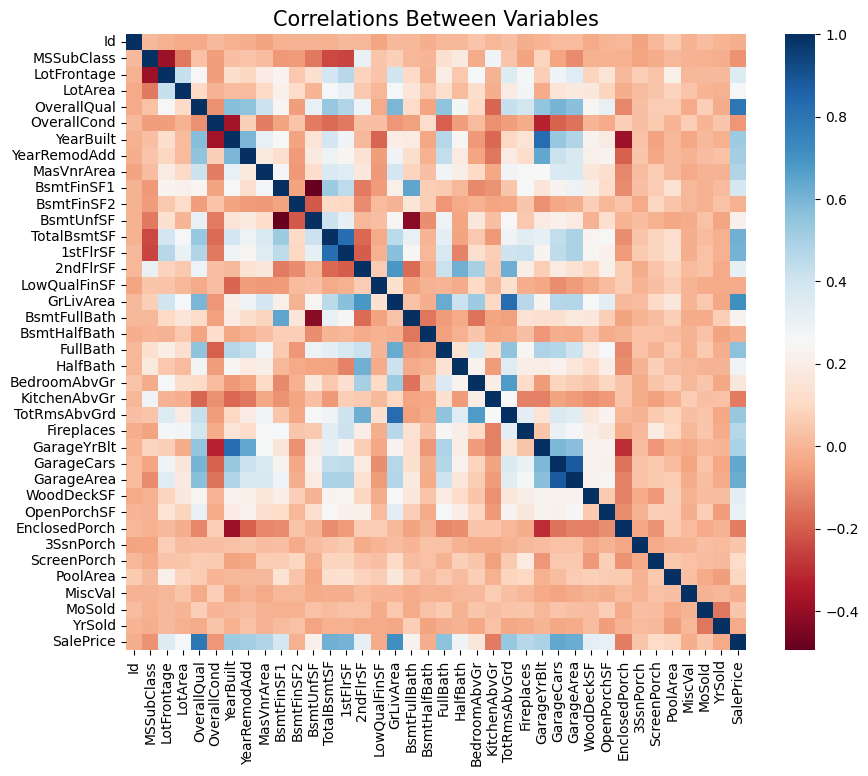

In [6]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

# Feature Selection

In [7]:
corr=df.corr(numeric_only=True)
important_num_cols = list(corr["SalePrice"][(corr["SalePrice"]>0.50) | (corr["SalePrice"]<-0.50)].index)
cat_cols = ["MSZoning", "Utilities","BldgType","Heating","KitchenQual","SaleCondition","LandSlope"]
important_cols = important_num_cols + cat_cols

df = df[important_cols]
print(df)

      OverallQual  YearBuilt  YearRemodAdd  TotalBsmtSF  1stFlrSF  GrLivArea  \
0               7       2003          2003          856       856       1710   
1               6       1976          1976         1262      1262       1262   
2               7       2001          2002          920       920       1786   
3               7       1915          1970          756       961       1717   
4               8       2000          2000         1145      1145       2198   
...           ...        ...           ...          ...       ...        ...   
1455            6       1999          2000          953       953       1647   
1456            6       1978          1988         1542      2073       2073   
1457            7       1941          2006         1152      1188       2340   
1458            5       1950          1996         1078      1078       1078   
1459            5       1965          1965         1256      1256       1256   

      FullBath  TotRmsAbvGrd  GarageCar

# missing values 

In [8]:
print("\nMISSING VALUES IN DATASET\n")

print(df.isnull())

print("\nNUMBER OF MISSING VALUES\n")

print(df.isnull().sum())




MISSING VALUES IN DATASET

      OverallQual  YearBuilt  YearRemodAdd  TotalBsmtSF  1stFlrSF  GrLivArea  \
0           False      False         False        False     False      False   
1           False      False         False        False     False      False   
2           False      False         False        False     False      False   
3           False      False         False        False     False      False   
4           False      False         False        False     False      False   
...           ...        ...           ...          ...       ...        ...   
1455        False      False         False        False     False      False   
1456        False      False         False        False     False      False   
1457        False      False         False        False     False      False   
1458        False      False         False        False     False      False   
1459        False      False         False        False     False      False   

      FullB

# Data Visualization

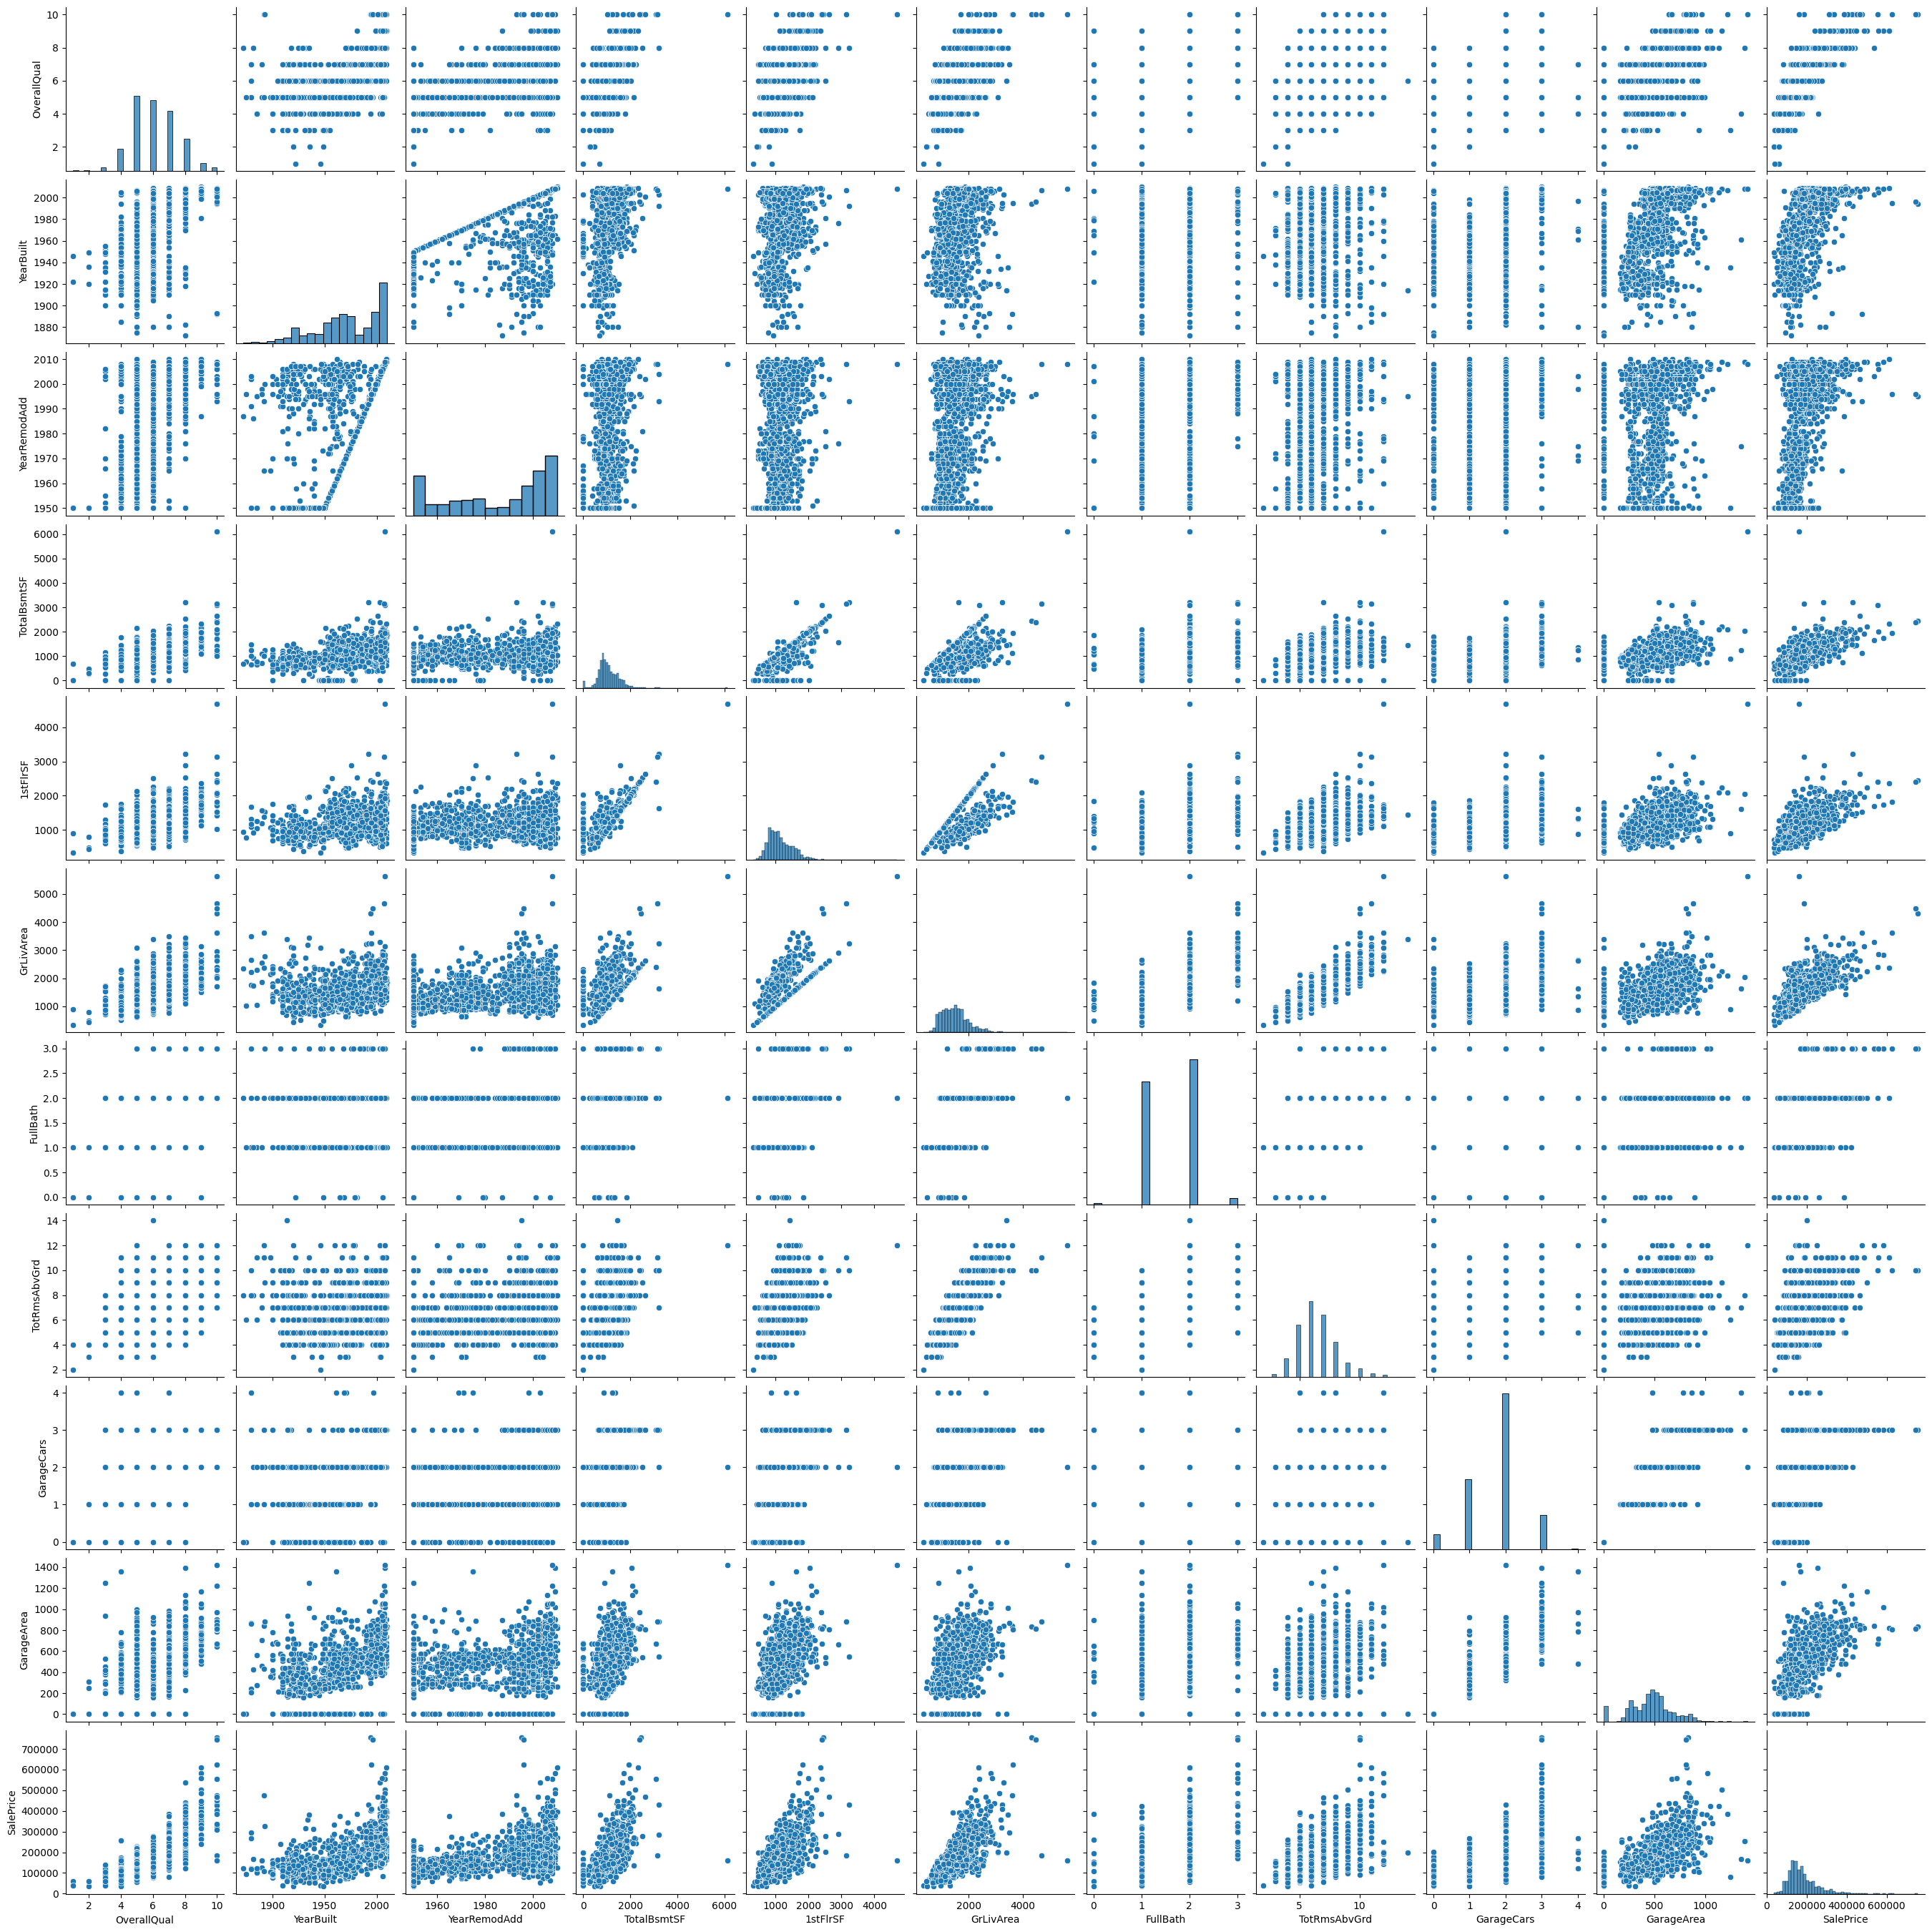

In [9]:
sns.pairplot(df[important_num_cols])

<Figure size 1000x800 with 0 Axes>

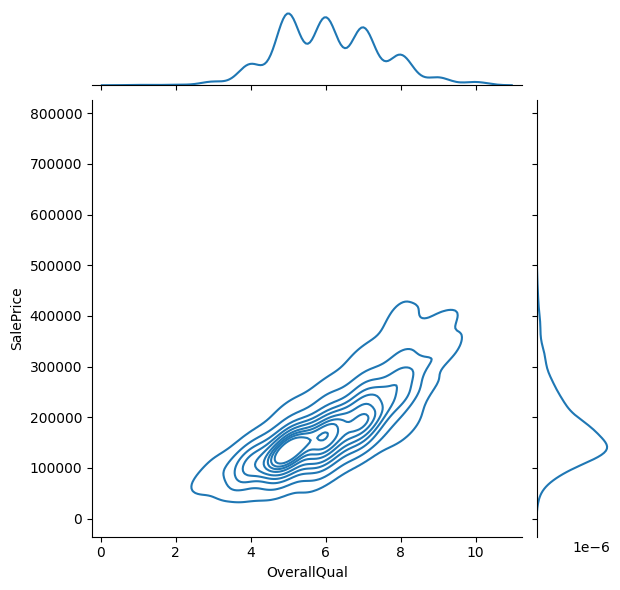

In [13]:
plt.figure(figsize=(10,8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="kde")
plt.show()

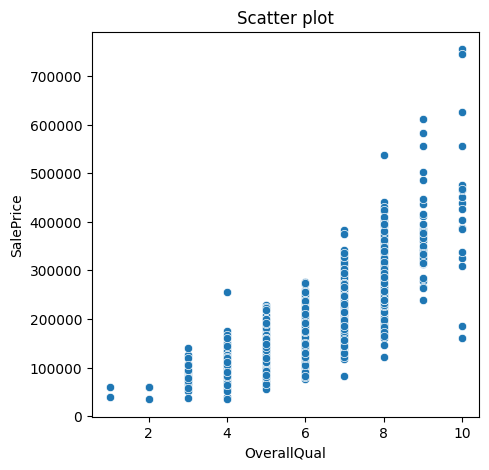

In [10]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=df['OverallQual'],y=df['SalePrice'])
plt.ylabel='SalePrice'
plt.xlabel='OverallQual'
plt.title("Scatter plot")
plt.show()


<Figure size 1000x800 with 0 Axes>

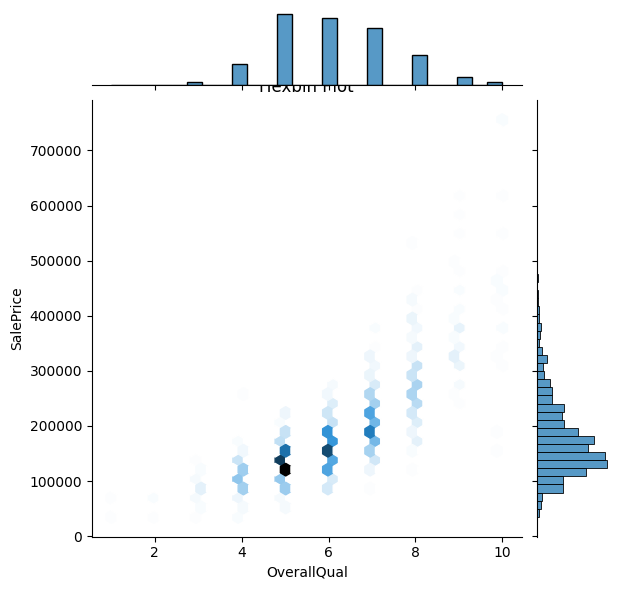

In [11]:
plt.figure(figsize=(10, 8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="hex")
plt.xlabel="Overall Quality"
plt.ylabel="Sale Price"
plt.title("Hexbin Plot")
plt.show()

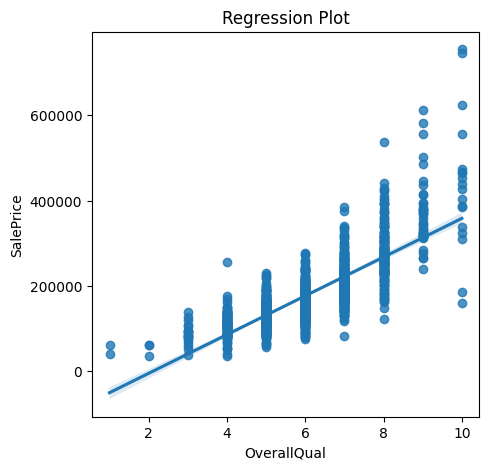

In [17]:
plt.figure(figsize=(5,5))
sns.regplot(x=df['OverallQual'] , y=df['SalePrice'])
plt.xlabel="Overall Quality"
plt.ylabel="Sale Price"
plt.title("Regression Plot")
plt.show()

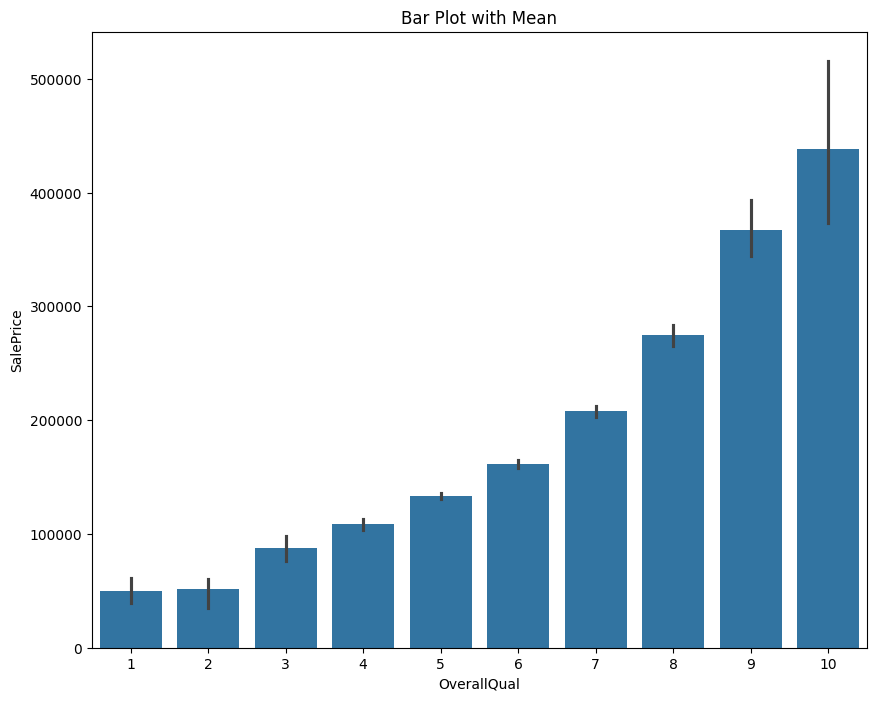

In [12]:
plt.figure(figsize=(10, 8))
sns.barplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel="Overall Quality"
plt.ylabel="Mean Sale Price"
plt.title("Bar Plot with Mean")
plt.show()

# X, y Split ✂

In [28]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [20]:
X = pd.get_dummies(X, columns=cat_cols)

In [21]:
X.head()

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,GarageCars,GarageArea,...,KitchenQual_TA,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev
0,7,2003,2003,856,856,1710,2,8,2,548,...,False,False,False,False,False,True,False,True,False,False
1,6,1976,1976,1262,1262,1262,2,6,2,460,...,True,False,False,False,False,True,False,True,False,False
2,7,2001,2002,920,920,1786,2,6,2,608,...,False,False,False,False,False,True,False,True,False,False
3,7,1915,1970,756,961,1717,1,7,3,642,...,False,True,False,False,False,False,False,True,False,False
4,8,2000,2000,1145,1145,2198,2,9,3,836,...,False,False,False,False,False,True,False,True,False,False


In [97]:
pip install scikit-learn

You should consider upgrading via the 'C:\Users\Admin\nest\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [22]:
import sklearn
print(sklearn.__version__)

1.7.2


In [22]:
important_num_cols.remove("SalePrice")

scaler = StandardScaler()
X[important_num_cols] = scaler.fit_transform(X[important_num_cols])


ValueError: list.remove(x): x not in list

In [ ]:
X.head()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=121)

In [23]:
def rmse_cv(model):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5)).mean()
    return rmse
    

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])


In [24]:
models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])

# prediction begins

In [ ]:
l_reg = LinearRegression()
l_reg.fit(X_train, y_train)
predictions = l_reg.predict(X_test)

In [ ]:
print(X_train.select_dtypes(include='object').columns)

In [35]:
cat_cols = ["MSZoning", "Utilities", "BldgType",
            "Heating", "KitchenQual",
            "SaleCondition", "LandSlope"]

X = pd.get_dummies(X, columns=cat_cols)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.select_dtypes(include='object').columns)

Index(['MSZoning', 'Utilities', 'BldgType', 'Heating', 'KitchenQual',
       'SaleCondition', 'LandSlope'],
      dtype='object')


In [37]:
l_reg = LinearRegression()
l_reg.fit(X_train, y_train)
predictions = l_reg.predict(X_test)

In [38]:
predictions


array([146279.75179158, 281901.93625801, 112045.95480672, 161515.27090027,
       324249.52482549,  44922.38639333, 210950.76358314, 148486.19670107,
        38583.56886176, 127571.75046928, 159130.20523604, 112288.7861192 ,
        71327.23923598, 222498.12649674, 184385.11731587, 130536.34097233,
       216448.70952555, 120309.83933586, 137208.01950475, 218315.87388267,
       177355.00047186, 225570.67987341, 187519.09988685, 120166.49045072,
       214622.30524268, 163835.62493814, 221765.03522439, 100509.32123704,
       187263.23997591, 203375.00552566, 125842.66401234, 246298.43319481,
       266338.2566972 ,  96419.94215315, 258508.91789305, 145057.15703896,
       162284.6278447 , 225124.19728035, 277496.96261879,  85644.48008715,
       132618.32420993, 234216.10409864, 118718.44659273, 346025.72882412,
       129287.47016889, 166030.10346319, 105305.19904565, 116559.57470974,
       371145.47154564, 138686.27406   , 109800.25072997, 221742.11977008,
        99459.48429479, 2

In [39]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(l_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "LinearRegression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)


MAE: 23567.890565943355
MSE: 1414931404.6297836
RMSE: 37615.57396384885
R2 Score: 0.8155317822983867
------------------------------
RMSE Cross-Validation: 35933.128976293636


In [40]:
ridge_reg = Ridge(alpha=0.5) 
ridge_reg.fit(X_train, y_train)
predictions_ridge = ridge_reg.predict(X_test)
predictions_ridge

array([ 1.46237268e+05,  2.81898883e+05,  1.11871407e+05,  1.61331458e+05,
        3.24059822e+05,  4.48697903e+04,  2.10904729e+05,  1.48666253e+05,
        3.86604445e+04,  1.27531685e+05,  1.58943509e+05,  1.12299099e+05,
        7.33355781e+04,  2.22531974e+05,  1.84475546e+05,  1.30464091e+05,
        2.16455516e+05,  1.20712115e+05,  1.36903121e+05,  2.18352667e+05,
        1.77566353e+05,  2.25507621e+05,  1.87578119e+05,  1.20170752e+05,
        2.14671386e+05,  1.63928554e+05,  2.21808499e+05,  1.00548023e+05,
        1.87327373e+05,  2.03380077e+05,  1.25906959e+05,  2.46381793e+05,
        2.65907624e+05,  9.64460896e+04,  2.58565453e+05,  1.45043406e+05,
        1.62212574e+05,  2.25117421e+05,  2.77501086e+05,  8.57973861e+04,
        1.32434051e+05,  2.34282774e+05,  1.18734172e+05,  3.45966581e+05,
        1.29336416e+05,  1.65760232e+05,  1.05313852e+05,  1.16567713e+05,
        3.70869455e+05,  1.38530493e+05,  1.09781700e+05,  2.21753606e+05,
        9.95510919e+04,  

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r_squared = r2_score(y, predictions)

    return mae, mse, rmse, r_squared

mae, mse, rmse, r_squared = evaluation(y_test, predictions_ridge)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r_squared)

MAE: 23494.21762249747
MSE: 1408903728.9105945
RMSE: 37535.36637506812
R² Score: 0.8163176257627158


In [42]:
lasso_reg = Lasso(alpha=0.5)  # You can adjust the alpha parameter
lasso_reg.fit(X_train, y_train)
predictions_lasso = lasso_reg.predict(X_test)
predictions_lasso

array([146277.88908073, 281903.97649838, 112041.81888327, 161511.69499243,
       324249.19200993,  44923.42678657, 210951.39889103, 148502.72489081,
        38608.5948613 , 127571.35536232, 159123.76610764, 112290.91362136,
        71502.8305103 , 222498.94287585, 184383.98469855, 130536.22670492,
       216451.6553802 , 120338.06709587, 137195.48501674, 218316.79404653,
       177365.81193828, 225564.58517737, 187524.43116279, 120169.29827503,
       214624.56858382, 163832.22862161, 221761.83113441, 100511.26129125,
       187266.12560975, 203356.2256839 , 125847.9334982 , 246302.0180569 ,
       266340.54562543,  96424.53691121, 258506.10856905, 145057.67927837,
       162284.59298862, 225126.53866677, 277489.39458338,  85664.58636753,
       132613.46834115, 234222.89646485, 118720.89532088, 346025.87998794,
       129288.3978904 , 165963.66574324, 105301.45767635, 116560.66848938,
       371139.42043744, 138648.09017637, 109800.63210461, 221740.97058468,
        99467.93262057, 2

In [43]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_lasso)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(lasso_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "Lasso Regression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 23563.90176086799
MSE: 1414591079.487492
RMSE: 37611.049965236176
R2 Score: 0.8155761513555949
------------------------------
RMSE Cross-Validation: 35924.15626504355


# random forest regression

In [44]:
rf_reg = RandomForestRegressor(n_estimators=100)  # You can adjust the number of estimators
rf_reg.fit(X_train, y_train)
predictions_rf = rf_reg.predict(X_test)
predictions_rf

array([139503.75      , 324116.81      , 110687.16      , 159139.        ,
       318823.07      ,  79611.        , 205604.4       , 152322.        ,
        80780.        , 131733.84      , 161556.5       , 114081.3       ,
       102598.5       , 217709.        , 185006.7       , 132222.2       ,
       194428.05      , 136793.        , 113461.5       , 193103.3       ,
       169359.5       , 226173.08      , 172358.05      , 128935.        ,
       188882.46      , 172265.14      , 182420.57      ,  96450.65      ,
       187163.        , 196050.        , 123809.        , 236957.25      ,
       184453.1       , 114765.        , 255454.72      , 141785.5       ,
       157706.09      , 204611.62      , 302654.83      , 108106.5       ,
       125470.        , 234400.29      , 118453.5       , 395732.06      ,
       133600.        , 149867.5       , 113391.32      , 121701.        ,
       402006.41      , 143939.1       , 123804.5       , 191090.        ,
       121208.16666667, 3

In [40]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_rf)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(rf_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "RandomForestRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 18037.88178652968
MSE: 956987935.726856
RMSE: 30935.221604618513
R2 Score: 0.8752350408734697
------------------------------
RMSE Cross-Validation: 31595.879423969258


# Support Vector Regression (SVR

In [45]:
svr_reg = SVR(kernel='rbf')  
svr_reg.fit(X_train, y_train)
predictions_svr = svr_reg.predict(X_test)
predictions_svr

array([164968.01402589, 165075.20787199, 164964.81081794, 164997.5683483 ,
       165042.10751288, 164923.13948921, 165009.95570818, 164978.21281743,
       164923.13079746, 164971.52446318, 164975.80218768, 164948.13360509,
       164969.57776155, 165025.75615803, 164995.78035398, 164961.40899217,
       164991.2138422 , 164971.29014252, 164962.80568945, 165019.70009422,
       165032.97935131, 164985.21733789, 164974.54135493, 164955.03142878,
       165017.11601514, 164987.95814523, 165001.65307676, 164949.2755347 ,
       164990.83494985, 165004.35717692, 164961.90180408, 165025.7285841 ,
       165081.66219866, 164956.1764108 , 165042.64826823, 164977.93569572,
       165017.26492441, 165002.3581621 , 165065.68942584, 164928.83983484,
       164963.36530805, 165025.96214647, 164955.98966059, 165083.70195081,
       164965.23491809, 165026.22074232, 164952.2070977 , 164958.32351993,
       165076.5253182 , 164980.44233484, 164956.26505331, 165033.01161585,
       164946.77625071, 1

In [42]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_svr)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(svr_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "Support Vector Regression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 59459.70333433085
MSE: 7847648055.273941
RMSE: 88586.9519470782
R2 Score: -0.023117901807183205
------------------------------
RMSE Cross-Validation: 81080.87570035845


# Gradient Boosting Regression

In [46]:
gb_reg = GradientBoostingRegressor(n_estimators=100)  # You can adjust the number of estimators
gb_reg.fit(X_train, y_train)
predictions_gb = gb_reg.predict(X_test)
predictions_gb

array([141559.29132744, 321057.54906208, 116411.61531314, 150971.30090716,
       321710.18259441,  80200.79675132, 215829.92624221, 152568.30707283,
        78126.85985751, 130456.00394599, 161971.96490193, 120888.84239996,
        99862.65936772, 213834.73327631, 172731.16194561, 136087.53207618,
       200201.40984191, 141105.07487073, 118576.09053254, 205219.0580473 ,
       186587.54125023, 204772.16846434, 174000.836146  , 130189.83340129,
       202816.37271244, 164206.10894387, 193706.97250692, 107343.25906595,
       178515.32829938, 190583.98732382, 123096.78205985, 243640.73521407,
       262419.34119152, 114154.06026445, 259244.9853728 , 140662.97515131,
       170948.2649447 , 219432.52632848, 318974.81867965,  95937.47252924,
       129132.5611489 , 242112.97518449, 125246.82754307, 403144.01157323,
       132763.27656327, 119643.72632468, 116096.15359416, 126209.03943711,
       426610.48939942, 137627.88693202, 120720.91320571, 205872.80957689,
       101499.11821509, 3

In [47]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(gb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "GradientBoostingRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 17480.52725722478
MSE: 772413323.3842156
RMSE: 27792.324900666652
R2 Score: 0.899298504063561
------------------------------
RMSE Cross-Validation: 28171.586452426523


In [45]:
from xgboost import XGBRegressor

In [48]:
xgb_reg = XGBRegressor(n_estimators=100)  # You can adjust the number of estimators
xgb_reg.fit(X_train, y_train)
predictions_xgb = xgb_reg.predict(X_test)

In [49]:
predictions_xgb

array([140956.47 , 318248.94 , 107999.805, 152414.58 , 318963.03 ,
        79742.086, 211526.02 , 149456.88 ,  73665.45 , 129488.875,
       147547.77 , 122980.87 ,  99900.45 , 224538.45 , 168908.67 ,
       133028.31 , 195112.05 , 135345.45 , 110156.945, 190547.34 ,
       182353.78 , 207547.64 , 169905.38 , 146498.52 , 199910.25 ,
       164704.45 , 194219.78 ,  89879.44 , 188837.9  , 216065.67 ,
       128302.2  , 244624.64 , 250628.83 , 129180.82 , 252398.8  ,
       148345.58 , 161897.58 , 210229.58 , 308034.7  , 104433.02 ,
       138050.58 , 247793.55 , 128002.82 , 425314.2  , 133568.44 ,
       146690.08 , 110970.06 , 127732.18 , 496216.06 , 145478.81 ,
       112071.016, 190035.14 , 115346.164, 383670.78 , 144639.92 ,
       240920.84 , 194787.12 , 165859.2  , 145645.33 , 111742.8  ,
        64480.07 , 153969.61 , 309975.62 , 272199.34 , 288516.66 ,
       225038.28 , 108901.27 , 367726.7  , 119754.89 , 159063.44 ,
       119453.96 , 132274.84 , 112687.92 ,  90116.68 , 476550.

In [50]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_xgb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(xgb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "XGBRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)


MAE: 18794.5859375
MSE: 879140544.0
RMSE: 29650.304281743887
R2 Score: 0.885384202003479
------------------------------
RMSE Cross-Validation: 31982.807244690077


In [25]:
!pip install lightgbm

     ---------------------------------------- 1.5/1.5 MB 649.5 kB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\Admin\nest\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [51]:
from lightgbm import LGBMRegressor

lgb_reg = LGBMRegressor(n_estimators=100)

lgb_reg.fit(X_train, y_train)

predictions_lgb = lgb_reg.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1239
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 28
[LightGBM] [Info] Start training from score 181441.541952


In [52]:
predictions_lgb

array([142837.79896625, 324129.18341384, 108751.65293773, 149150.96627579,
       324741.67413668,  74432.13157812, 194492.26269399, 148199.9782445 ,
        74083.17827511, 127031.46299979, 152029.63204485, 114479.26924173,
       116855.04713324, 224093.37037237, 167161.07021305, 131374.04644144,
       193453.33147407, 138613.59385652, 108317.81145285, 201885.57766586,
       181470.19755978, 226672.86575643, 176303.44788435, 141740.73778555,
       197253.50009664, 166196.14626625, 198904.6386527 ,  98187.92582517,
       185208.34591535, 203559.48452465, 126904.56834232, 237220.09885959,
       232971.10368413, 120795.98426426, 250862.24844372, 142708.58263755,
       170593.09808211, 216614.57041124, 318928.3000109 ,  96686.27429269,
       127949.24946192, 238658.28548764, 125458.57260022, 388740.10227975,
       136244.22100221, 130486.21906365, 116555.47586012, 124080.5073072 ,
       433133.24999324, 132664.99557317, 121020.57209714, 214568.65827886,
       108639.62653714, 3

In [53]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_lgb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(lgb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "LGBMRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)

MAE: 18305.016967174597
MSE: 953086780.378385
RMSE: 30872.10359496717
R2 Score: 0.8757436444508268
------------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1239
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 28
[LightGBM] [Info] Start training from score 180717.091610
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1241
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 28
[LightGBM] [Info] Start training from score 180407.575342
[LightGBM] [Warnin

In [54]:
models.sort_values(by="RMSE (Cross-Validation)")

,Model,MAE,MSE,RMSE,R2 Score,RMSE (Cross-Validation)
2,GradientBoostingRegressor,17480.527257,7.724133e+08,27792.324901,0.899299,28171.586452
4,LGBMRegressor,18305.016967,9.530868e+08,30872.103595,0.875744,31616.349646
3,XGBRegressor,18794.585938,8.791405e+08,29650.304282,0.885384,31982.807245
1,Lasso Regression,23563.901761,1.414591e+09,37611.049965,0.815576,35924.156265
0,LinearRegression,23567.890566,1.414931e+09,37615.573964,0.815532,35933.128976


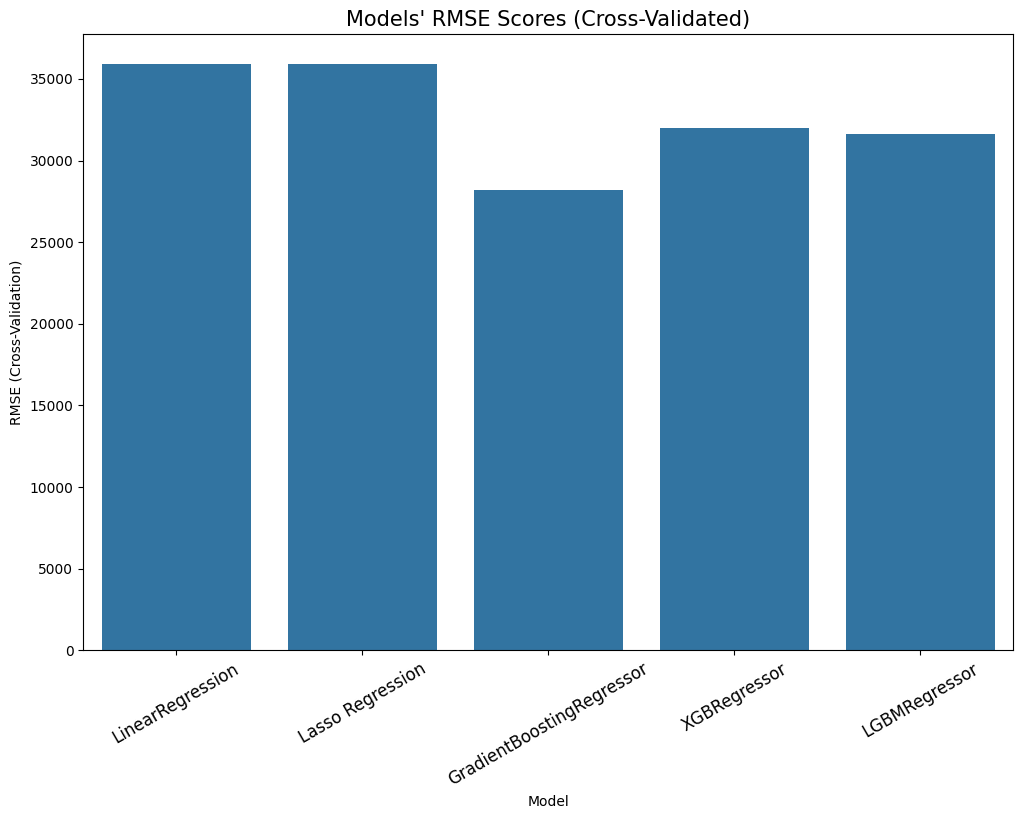

In [55]:
plt.figure(figsize=(12,8))
sns.barplot(x=models["Model"], y=models["RMSE (Cross-Validation)"])
plt.title("Models' RMSE Scores (Cross-Validated)", size=15)
plt.xticks(rotation=30, size=12)
plt.show()

In [56]:
gb_reg_full = GradientBoostingRegressor(n_estimators=100)  # You can adjust the number of estimators
gb_reg_full.fit(X, y)
predictions_gb_full = gb_reg_full.predict(X_test)
mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb_full)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(gb_reg_full)
print("RMSE Cross-Validation:", rmse_cross_val)
new_row = {"Model": "GradientBoostingRegressor - Selected","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat(
    [models, pd.DataFrame([new_row])],
    ignore_index=True
)


MAE: 13385.827848826182
MSE: 331111737.7072847
RMSE: 18196.475969464107
R2 Score: 0.9568321178573824
------------------------------
RMSE Cross-Validation: 28343.30340717956


# Making this to an API

# 1. Feature Selection

In [57]:
corr = df.corr(numeric_only=True)

important_num_cols = list(
    corr["SalePrice"][
        (corr["SalePrice"] > 0.50) |
        (corr["SalePrice"] < -0.50)
    ].index
)

cat_cols = [
    "MSZoning",
    "Utilities",
    "BldgType",
    "Heating",
    "KitchenQual",
    "SaleCondition",
    "LandSlope"
]

important_cols = important_num_cols + cat_cols

df = df[important_cols]

# 2. Data Preprocessing

In [58]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [59]:
X = pd.get_dummies(X, columns=cat_cols)

In [60]:
from sklearn.preprocessing import StandardScaler

important_num_cols.remove("SalePrice")

scaler = StandardScaler()
X[important_num_cols] = scaler.fit_transform(
    X[important_num_cols]
)

In [61]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def evaluation(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_reg.fit(X_train, y_train)

predictions = gb_reg.predict(X_test)

mae, mse, rmse, r2 = evaluation(
    y_test,
    predictions
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 17361.588228535227
MSE : 754280597.6301918
RMSE: 27464.169341711244
R²  : 0.9016625137893838


In [63]:
final_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

final_model.fit(X, y)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [64]:
import joblib

joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [65]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import GradientBoostingRegressor

import joblib

In [66]:
import joblib

joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

joblib.dump(important_num_cols, "num_cols.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Saved successfully")

Saved successfully
